# MicroProyecto # 2 de Machine Learning No Supervisado — MAIA

**Nombre de los estudiantes:**  Jairo Alexander López Garcia -  Miguel Angel Rodriguez Marin

**Código:**  `202615506`  -  `202612426`

**Maestría:** Maestría en Inteligencia Artificial (MAIA)

**Fecha:**  06/15/2026


## 0. Importación de librerías requeridas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1. Carga del Dataset

Con la libreria pandas cargamos la fuente de datos

In [2]:
df = pd.read_excel('./data/Datos_textosODS.xlsx')
df.head()

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


## 2. Preparacion de los Datos

### Verificacion de nulos y Duplicados

Realizamos una exploración del texto. Aplicando tokenización, eliminación de palabras vacías y reducción de palabras a su raíz, adaptando al idioma español.

In [3]:
print(df.isnull().sum())
print(df.duplicated(subset='textos').sum())

textos    0
ODS       0
dtype: int64
0


El dataset no presenta valores nulos ni textos duplicados.

In [4]:
df['ODS'].value_counts().sort_index()

ODS
1      505
2      369
3      894
4     1025
5     1070
6      695
7      787
8      446
9      343
10     352
11     607
12     312
13     464
14     377
15     330
16    1080
Name: count, dtype: int64

La cantidad de textos varía entre los distintos ODS.

### Definicion de Tokenizador

Definimos el tokenizador, las palabras vacías y el stemmer en español, y usamos SnowballStemmer para el idioma español.

In [5]:
tokenizer = RegexpTokenizer(r'[a-zA-ZáéíóúñÁÉÍÓÚÑüÜ]+')
stopwords_es = stopwords.words('spanish')
stemmer = SnowballStemmer('spanish')

### Prueba de Tokenizador

Probamos sobre un texto de ejemplo para verificar que separa correctamente las palabras, incluyendo tildes y la letra ñ.

In [6]:
texto_ejemplo = df['textos'].iloc[0]
tokenizer.tokenize(texto_ejemplo.lower())

['aprendizaje',
 'y',
 'educación',
 'se',
 'consideran',
 'sinónimos',
 'de',
 'escolarización',
 'formal',
 'las',
 'organizaciones',
 'auxiliares',
 'como',
 'las',
 'editoriales',
 'de',
 'educación',
 'las',
 'juntas',
 'examinadoras',
 'y',
 'las',
 'organizaciones',
 'de',
 'formación',
 'de',
 'docentes',
 'se',
 'consideran',
 'extensiones',
 'de',
 'los',
 'acuerdos',
 'establecidos',
 'por',
 'los',
 'gobiernos',
 'este',
 'marco',
 'de',
 'comprensión',
 'se',
 'ha',
 'vuelto',
 'cada',
 'vez',
 'más',
 'inadecuado']

### Funcion de preprocesamiento

Utilizamos los tres pasos anteriores en la función text_preprocess y como parámetro preprocessor TfidfVectorizer, para que el procesamiento se aplique automáticamente.

In [7]:
def text_preprocess(text):
    tokenizer = RegexpTokenizer(r'[a-zA-ZáéíóúñÁÉÍÓÚÑüÜ]+')
    stemmer = SnowballStemmer('spanish')
    
    tokens = tokenizer.tokenize(text.lower())
    tokens = [token for token in tokens if token not in stopwords_es]
    tokens = [stemmer.stem(token) for token in tokens]
    
    return ' '.join(tokens)

### Prueba de la Funcion

Verificamos que la función produce el mismo resultado que obtuvimos al aplicar los pasos por separado sobre el texto de ejemplo.

In [8]:
text_preprocess(df['textos'].iloc[0])

'aprendizaj educ consider sinon escolariz formal organiz auxiliar editorial educ junt examin organiz formacion docent consider extension acuerd establec gobi marc comprension vuelt cad vez inadecu'

### Separacion de datos

Dividimos el conjunto en entrenamiento y prueba, usando el parámetro stratify=y para mantener la misma proporción.

In [9]:
X = df['textos']
y = df['ODS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=32)

### Vectorizador TF-IDF

Construimos el vectorizador TF-IDF usando text_preprocess como función de preprocesamiento, basado en el esquema de bolsa de palabras con ponderación TF-IDF. 

In [10]:
vectorizer = TfidfVectorizer(preprocessor=text_preprocess)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_train_tfidf.shape

(7724, 15218)

El vocabulario resultante contiene 15,218 términos.

Exploramos un número de componentes entre 10 y 20, evaluamos la varianza para fijar el número de componentes del LSA.

In [11]:
componentes_a_probar = [10, 12, 15, 18, 20]
varianza_acumulada = []

for n in componentes_a_probar:
    tsvd_prueba = TruncatedSVD(n_components=n, random_state=32)
    tsvd_prueba.fit(X_train_tfidf)
    varianza_acumulada.append(tsvd_prueba.explained_variance_ratio_.sum())
    print(n, tsvd_prueba.explained_variance_ratio_.sum())

10 0.051652370584320186
12 0.058171384320575864
15 0.06694615542977432
18 0.07462046308532994
20 0.07940725090979227


Elegimos 18 componentes, cercano al extremo superior del rango permitido, buscando retener la mayor información posible para el clasificador.

Construimos el modelo LSA definitivo con 18 componentes sobre la matriz TF-IDF de entrenamiento.

In [12]:
tsvd = TruncatedSVD(n_components=18, random_state=32)
X_train_lsa = tsvd.fit_transform(X_train_tfidf)
X_train_lsa.shape

(7724, 18)

Extraemos las 10 palabras con mayor peso absoluto en cada uno de los primeros 5 componentes.

In [13]:
terminos = vectorizer.get_feature_names_out()

def mostrar_topico(componente_idx, n_palabras=10):
    pesos = tsvd.components_[componente_idx]
    indices_top = np.argsort(np.abs(pesos))[::-1][:n_palabras]
    
    print(f"--- Tópico {componente_idx} ---")
    for idx in indices_top:
        print(f"  {terminos[idx]}: {pesos[idx]:.4f}")
    print()

for i in range(5):
    mostrar_topico(i)

--- Tópico 0 ---
  pais: 0.1459
  polit: 0.1362
  pued: 0.1359
  mujer: 0.1350
  desarroll: 0.1338
  trabaj: 0.1160
  agu: 0.1152
  educ: 0.1108
  gener: 0.1070
  mejor: 0.1025

--- Tópico 1 ---
  agu: 0.4442
  mujer: -0.4048
  trabaj: -0.2138
  energ: 0.2064
  hombr: -0.1715
  derech: -0.1602
  educ: -0.1521
  niñ: -0.1258
  emple: -0.1144
  laboral: -0.1122

--- Tópico 2 ---
  derech: 0.5710
  internacional: 0.2480
  human: 0.2330
  pobrez: -0.1614
  ingres: -0.1537
  articul: 0.1428
  polit: 0.1126
  tribunal: 0.1037
  ley: 0.1032
  trabaj: -0.1027

--- Tópico 3 ---
  mujer: 0.3443
  agu: 0.3016
  escuel: -0.2885
  educ: -0.2874
  estudi: -0.2077
  docent: -0.1729
  evalu: -0.1560
  gener: 0.1472
  hombr: 0.1406
  aprendizaj: -0.1294

--- Tópico 4 ---
  agu: 0.6666
  energ: -0.3396
  energet: -0.1561
  electr: -0.1381
  educ: 0.1370
  renov: -0.1354
  escuel: 0.1115
  mujer: 0.1033
  tecnolog: -0.1025
  climat: -0.1014



En conjunto, el LSA logra capturar relaciones semánticas alineadas con los ODS, contrastando pares de temas en cada componente en lugar de aislar un único tema por eje.

### Contruccion del Modelo

Construimos un pipeline que integra los tres pasos del proceso: vectorización TF-IDF, reducción de dimensionalidad con LSA (18 componentes) y clasificación con Regresión Logística.

In [14]:
steps = [
    ("vectorizer", TfidfVectorizer(preprocessor=text_preprocess)),
    ("dimred", TruncatedSVD(n_components=18, random_state=32)),
    ("model", LogisticRegression(max_iter=500, random_state=32)),
]

pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('dimred', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](16,)","[ 1, 2, 3,...,14,15,16]"
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function tex...x7f0176d4c220>
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None


Evaluamos primero el modelo con sus hiperparámetros por defecto, antes de aplicar la búsqueda de hiperparámetros.

In [15]:
y_pred_base = pipeline.predict(X_test)
print(classification_report(y_test, y_pred_base))

              precision    recall  f1-score   support

           1       0.88      0.77      0.82       101
           2       0.56      0.61      0.58        74
           3       0.78      0.90      0.84       179
           4       0.82      0.94      0.88       205
           5       0.91      0.88      0.90       214
           6       0.86      0.95      0.90       139
           7       0.79      0.90      0.84       158
           8       0.63      0.49      0.55        89
           9       0.53      0.42      0.47        69
          10       0.78      0.64      0.70        70
          11       0.67      0.81      0.74       122
          12       0.92      0.19      0.32        62
          13       0.75      0.73      0.74        93
          14       0.53      0.56      0.54        75
          15       0.67      0.09      0.16        66
          16       0.76      0.92      0.83       216

    accuracy                           0.77      1932
   macro avg       0.74   

### Busqueda de Hiperparametros

Realizamos una búsqueda de hiperparámetros sobre el pipeline completo con GridSearchCV, evaluando distintos valores del parámetro de regularización C (0.1, 1, 10). Usamos f1_macro como métrica de optimización para que la evaluación refleje ese mismo criterio

In [16]:
param_grid = {
    'model__C': [0.1, 1, 10],
    'model__class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=32),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
{'model__C': 10, 'model__class_weight': None}
0.7249253802079593


La configuración balanceada no resulto ganadora. Como f1_macro pondera todas las clases por igual.

### Evaluacion del Modelo

Evaluamos el mejor modelo encontrado por la búsqueda de hiperparámetros sobre el conjunto de prueba.

In [17]:
mejor_pipeline = grid.best_estimator_
y_pred_final = mejor_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           1       0.86      0.79      0.82       101
           2       0.57      0.61      0.59        74
           3       0.85      0.89      0.87       179
           4       0.86      0.92      0.89       205
           5       0.91      0.90      0.91       214
           6       0.86      0.96      0.90       139
           7       0.83      0.89      0.86       158
           8       0.62      0.51      0.56        89
           9       0.56      0.54      0.55        69
          10       0.74      0.64      0.69        70
          11       0.73      0.82      0.77       122
          12       0.75      0.48      0.59        62
          13       0.76      0.73      0.74        93
          14       0.59      0.52      0.55        75
          15       0.62      0.55      0.58        66
          16       0.86      0.90      0.88       216

    accuracy                           0.79      1932
   macro avg       0.75   

### Matriz de Confusion

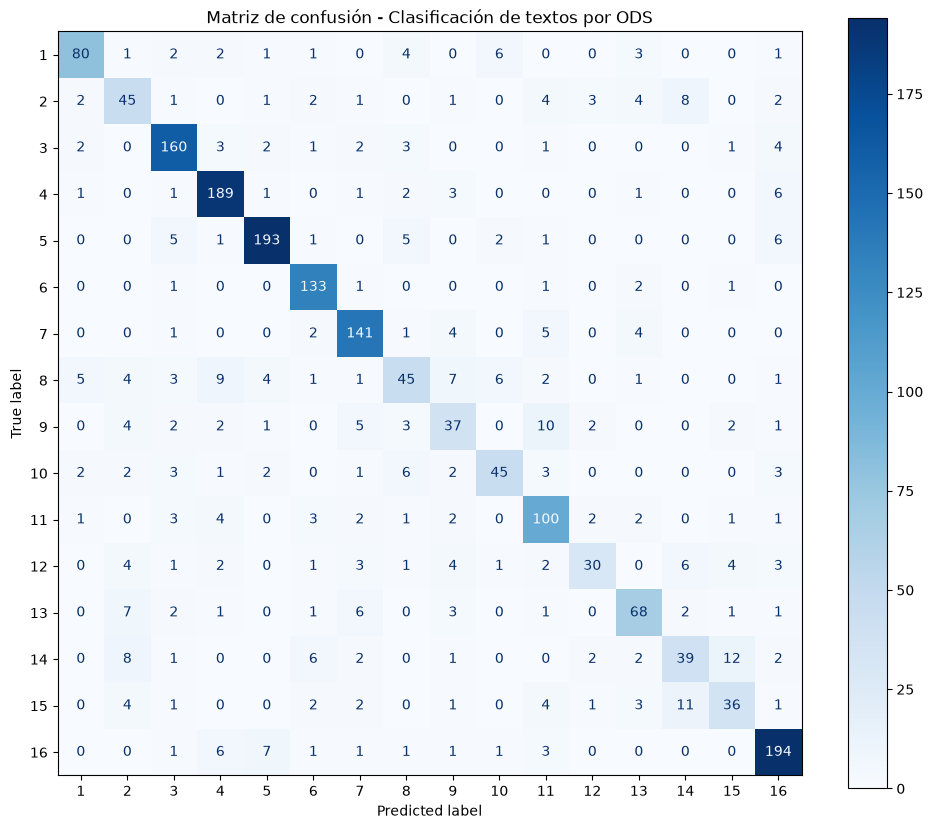

In [18]:
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, ax=ax, cmap='Blues')
plt.title("Matriz de confusión - Clasificación de textos por ODS")
plt.show()

El modelo alcanza un accuracy de 0.79 y un f1-score macro de 0.72 sobre el conjunto de prueba. La matriz de confusión muestra que los errores no son aleatorios.

### Calsifiacion de prueba

Seleccionamos 4 textos del conjunto de prueba.

In [19]:
idx_ods4_test = X_test[y_test == 4].index
idx_ods12_test = X_test[y_test == 12].index
idx_ods15_test = X_test[y_test == 15].index
idx_ods16_test = X_test[y_test == 16].index

ejemplos_idx = [idx_ods4_test[0], idx_ods12_test[0], idx_ods15_test[2], idx_ods16_test[0]]

for idx in ejemplos_idx:
    texto = df.loc[idx, 'textos']
    ods_real = df.loc[idx, 'ODS']
    ods_predicho = mejor_pipeline.predict([texto])[0]
    
    print(f"Texto: {texto[:200]}...")
    print(f"ODS real: {ods_real} | ODS predicho: {ods_predicho}")
    print()

Texto: Dado el alcance del cambio en las prácticas docentes que requiere el nuevo currículo, Costa Rica podría encontrar valor en estándares que ofrezcan una guía más específica a los docentes en cuanto a lo...
ODS real: 4 | ODS predicho: 4

Texto: Es evidente que la escasez de recursos naturales presenta un problema global a largo plazo, motivo por el cual aquellas empresas que quieran anticiparse al futuro deberían explorar la posibilidad de i...
ODS real: 12 | ODS predicho: 12

Texto: El sector forestal contribuye a las actividades al aire libre construyendo y manteniendo caminos forestales y llevando a cabo medidas silvícolas para aumentar la accesibilidad de los bosques. El uso d...
ODS real: 15 | ODS predicho: 14

Texto: El 26 de junio de 2002 se adoptó en Alemania el código penal internacional tras el voto unánime del Bundestag (Deutscher Bundestag, 2002).1 Tras la ratificación del Tratado de Roma, la nueva norma ada...
ODS real: 16 | ODS predicho: 16



### Conclusion

El modelo logra identificar correctamente a qué Objetivo de Desarrollo Sostenible pertenece un texto la mayoría de las veces.

Cuando el modelo se equivoca confunde principalmente ODS que están relacionados entre sí.